In [22]:
import torch
import numpy as np
from einops import rearrange
import hdf5plugin
import h5py
from omegaconf import OmegaConf

from transformers import AutoImageProcessor, AutoModel

import matplotlib.pyplot as plt

conf = OmegaConf.load("../config/transpressor_v2.yaml")

pixel_preprocessor = AutoImageProcessor.from_pretrained(conf.pixel_preprocessor.model_name)
pixel_encoder = AutoModel.from_pretrained(conf.pixel_encoder.model_name).to("mps")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

5.151849


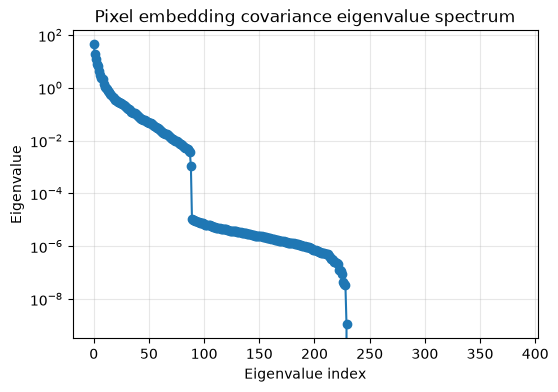

In [31]:
with torch.no_grad():
    with h5py.File("../data/pusht_expert_train.h5", "r") as data:
        # Sample 100 unique datapoints from dataset
        embeddings = []

        pixels_arr = data["pixels"][:100]
        starts = np.random.randint(0, len(pixels_arr) - 10, size=2000)

    pixels = torch.tensor(np.stack([pixels_arr[s] for s in starts])).to("mps")
    B, C, H, W = pixels.shape

    pixels = pixel_preprocessor(list(pixels), return_tensors="pt")["pixel_values"].to("mps")

    encoded = pixel_encoder(pixels).last_hidden_state[:, 0, :]

    cov = torch.cov(encoded.T)

    eigenvalues, eigenvectors = torch.linalg.eigh(cov.cpu())

    eigenvalues = eigenvalues.numpy()[::-1]  # descending, largest first
    r_eff = r_eff = (eigenvalues.sum())**2 / (eigenvalues**2).sum()
    print(r_eff)

plt.figure(figsize=(6,4))
plt.plot(eigenvalues, marker='o')
plt.yscale('log')
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Pixel embedding covariance eigenvalue spectrum")
plt.grid(True, which="both", alpha=0.3)
plt.show()


